<a href="https://colab.research.google.com/github/joaoValinhos-jv/Analogic_to_Digital_Converter/blob/main/ADC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insert the begin of the time interval in seconds: -20
Insert the end of the time interval in seconds: 20
Wish smoothing the graph line? [y/n]: y
How many stems do you want to see on the discrete plot? (e.g., 20): 50
Equation: cos(t)-t*sin(t)
['cos', '(', 't', ')', '-', 't', '*', 'sin', '(', 't', ')']
Decimals found: []
cos(t)-t*sin(t)
OP: -     POS: 6
VBOP:  5     VAOP:  7
OP: *     POS: 8
VBOP:  7     VAOP:  9
[6, 8]
['LOW', 'MEDIUM']
Location of the highest priority operator:  8
['cos', '(', 't', ')', '-', 't', '*', 'sin', '(', 't', ')']
['(', array([-20.        , -19.91983968, -19.83967936, -19.75951904,
       -19.67935872, -19.5991984 , -19.51903808, -19.43887776,
       -19.35871743, -19.27855711, -19.19839679, -19.11823647,
       -19.03807615, -18.95791583, -18.87775551, -18.79759519,
       -18.71743487, -18.63727455, -18.55711423, -18.47695391,
       -18.39679359, -18.31663327, -18.23647295, -18.15631263,
       -18.0761523 , -17.99599198, -17.91583166, -17.83567134,
       

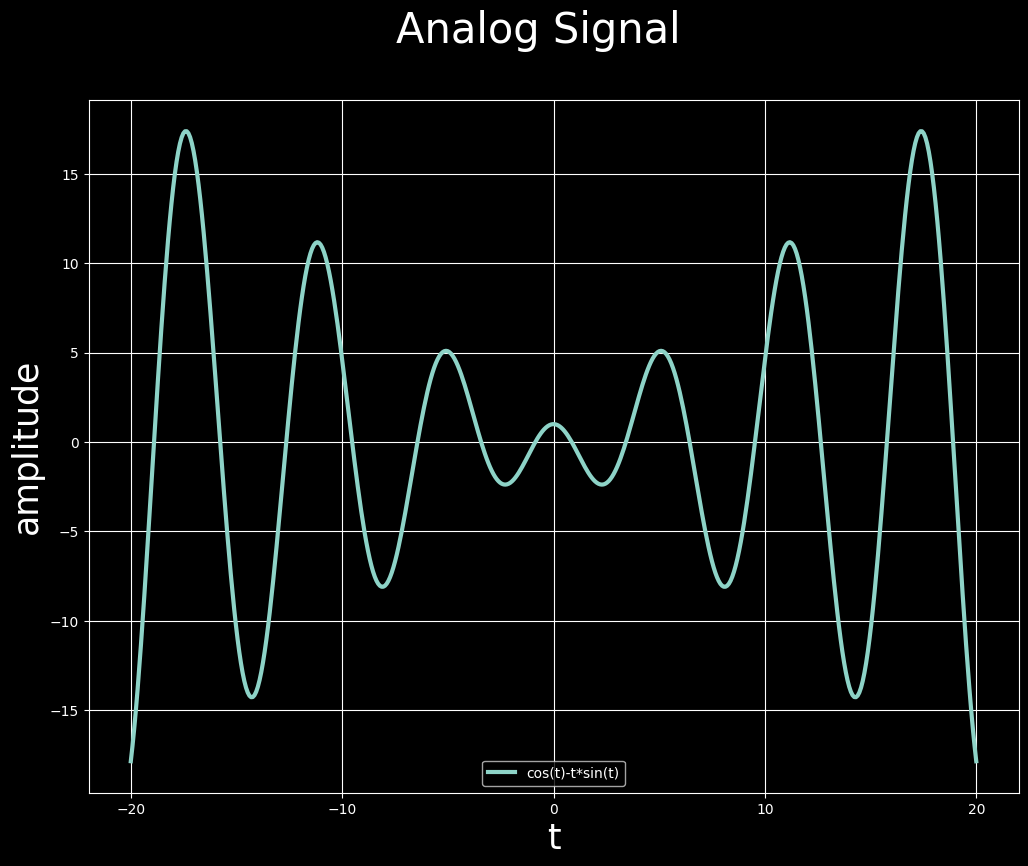

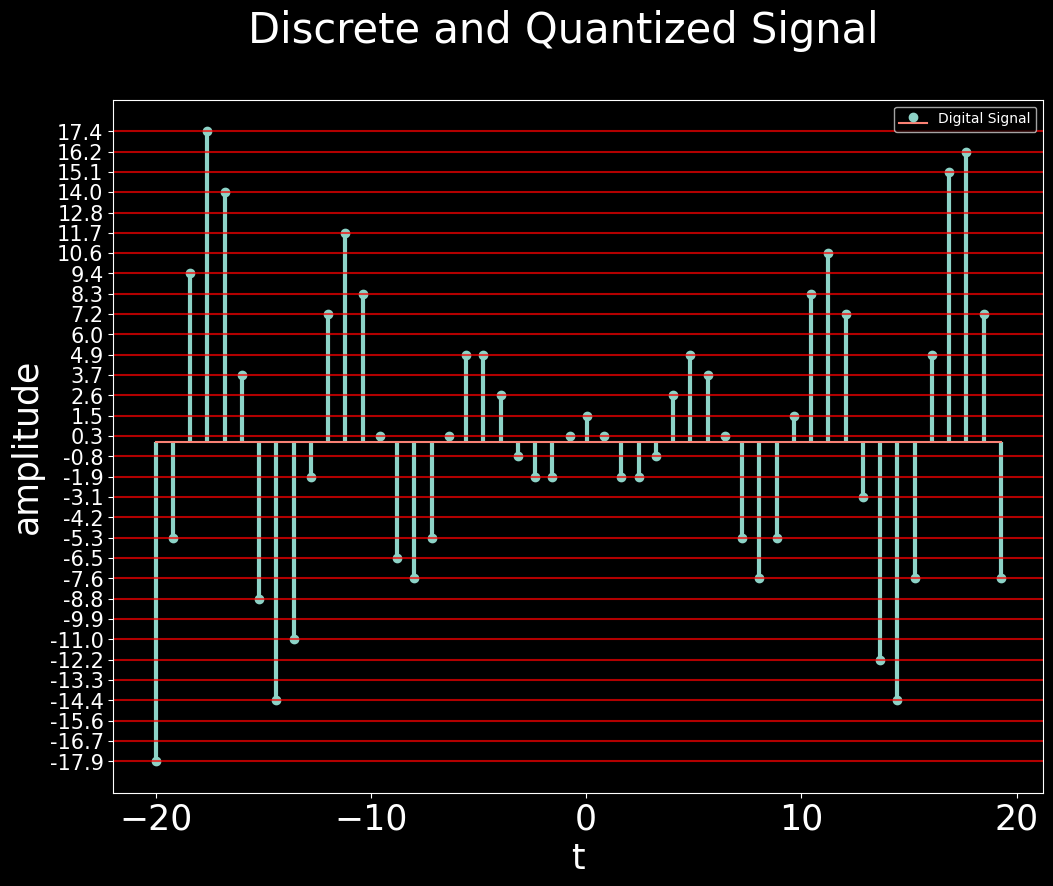


--- DIGITAL BITSTREAM ---
['00000', '01011', '11000', '11111', '11100', '10011', '01000', '00011', '00110', '01110', '10110', '11010', '10111', '10000', '01010', '01001', '01011', '10000', '10100', '10100', '10010', '01111', '01110', '01110', '10000', '10001', '10000', '01110', '01110', '01111', '10010', '10100', '10011', '10000', '01011', '01001', '01011', '10001', '10111', '11001', '10110', '01101', '00101', '00011', '01001', '10100', '11101', '11110', '10110', '01001']


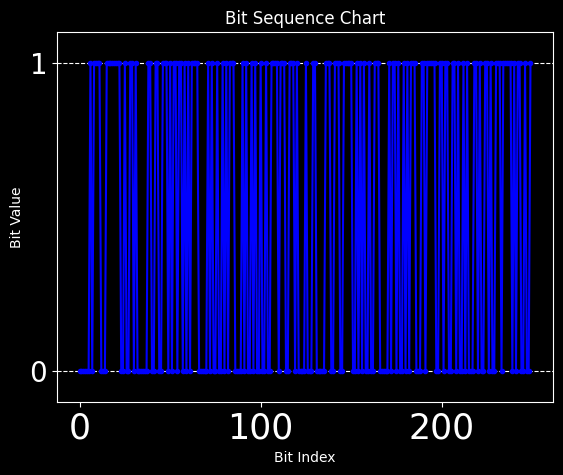

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import pandas as pd
import operator

# Example sugested
# Interval: -50 ~ 50
# Number of stems: 80
# Equation: cos(t)-t*sin(t)
# Disclaimer: Naturally -as all ADCs- some information is loss
# the accuracy can be improved by adjusting the bits
# and the stems (number of samples)

sm_flag = False
bits = 5

#=========================================================#
#         Analogic to Digital Signal Converter            #
#=========================================================#
def insert_time_interval():
  # Function made for choosing the time interval analysed
  begin_time = float(input("Insert the begin of the time interval in seconds: "))
  end_time = float(input("Insert the end of the time interval in seconds: "))
  interval = end_time - begin_time
  return interval, begin_time, end_time

time, bg, ed = insert_time_interval()

# Smoothing the graph line
smt = str(input("Wish smoothing the graph line? [y/n]: "))
if smt.lower() == 'y':
  sm_flag = True
  t = np.linspace(bg, ed, 500)
  num_stems = int(input("How many stems do you want to see on the discrete plot? (e.g., 20): "))
else:
  sm_flag = False
  passo = float(input("Insert the step size between points (e.g., 0.5 or 1.0): "))
  t = np.arange(bg, ed + passo, passo)


class AnalogSignal:
  # Class that represents the signal wave by
  # using a function that approaches the signal shape
  def __init__(self):
    self.equation = str(input("Equation: "))
    self.conv_chars = []
    # Dictionary for knowing what each string represents
    # The string reffers to the awnser of the equation input below in the code
    self.operators = {
        '+': operator.add,
        '-': operator.sub,
        '*': operator.mul,
        '/': operator.truediv,
        '^': operator.pow,
        'sin': np.sin,
        'cos': np.cos,
        'tan': np.tan
    }

  def get_equation(self, interval):
    # Uses regex for finding a pattern in the awnser
    chars = re.findall(r'sin|cos|tan|\d+\.\d+|\d+|[t+\-*/^()]', self.equation)
    print(chars)
    return chars, self.equation

  def format_equation(self, chars):
    # Turn string numbers into float, sepparates each part
    # of the equation's awnser and interprets
    decimals_found = []
    for i in chars:
      try:
        f = float(i)
        self.conv_chars.append(f)
      except ValueError:
        self.conv_chars.append(i)

    for index, item in enumerate(self.conv_chars):
      try:
        numero = float(item)
        if "." in str(item):
          decimals_found.append((index, item))
      except ValueError:
        pass

    print("Decimals found:", decimals_found)
    eq = "".join(str(item) for item in self.conv_chars)
    # Puts the equation's parts together
    return eq

class Processor(AnalogSignal):
  # Class that defines the preference for each operator
  # and calculates each value according to the chosen function
  # applied on t

  def __init__(self):
    super().__init__()
    self.preferable = []

  def process_equation(self, time):
    sequel = []
    usage_operators = []
    list_chars, typ_eq = self.get_equation(time)
    eq = super().format_equation(list_chars)
    priority = None
    map_op = []
    grad = []

    print(eq)
    for i in eq:
      if i in self.operators:
        pos = eq.find(i)
        print("OP:", i, "    POS:", pos)
        vl_bf = pos-1
        vl_af = pos+1
        print("VBOP: ", vl_bf, "    VAOP: ", vl_af)

        if i == '^':
          priority = "HIGH"
        elif i == '*' or i == '/':
          priority = "MEDIUM"
        else:
          priority = "LOW"

        map_op.append(pos)
        grad.append(priority)

    print(map_op)
    print(grad)

    if 'HIGH' in grad:
      loc = grad.index('HIGH')
    elif 'MEDIUM' in grad:
        loc = grad.index('MEDIUM')
    elif 'LOW' in grad:
        loc = grad.index('LOW')
    else:
        loc = None

    if loc is not None:
        print("Location of the highest priority operator: ", map_op[loc])
    else:
        print("No operator found.")

    print(self.conv_chars)
    for n in self.conv_chars:
      if n == 't':
        t_value = globals()['t']
        sequel.append(t_value)
      elif n in self.operators:
        usage_operators.append(n)
      else:
        sequel.append(n)
    print(sequel)
    print(usage_operators)

    precedence_order = ['^', '*', '/', '+', '-']
    num_and_ops = self.conv_chars.copy()

    for idx, item in enumerate(num_and_ops):
        if item == 't':
            num_and_ops[idx] = t

    while any(isinstance(item, str) and item == '(' for item in num_and_ops):
        open_idx = max(idx for idx, item in enumerate(num_and_ops) if isinstance(item, str) and item == '(')

        close_idx = None
        for idx in range(open_idx, len(num_and_ops)):
            if isinstance(num_and_ops[idx], str) and num_and_ops[idx] == ')':
                close_idx = idx
                break

        sub_expression = num_and_ops[open_idx + 1 : close_idx]

        sub_num = [item for item in sub_expression if not isinstance(item, str)]
        sub_ops = [item for item in sub_expression if isinstance(item, str) and item in precedence_order]

        while len(sub_ops) > 0:
            sub_op_index = None
            for op_search in precedence_order:
                if op_search in sub_ops:
                    sub_op_index = sub_ops.index(op_search)
                    break

            current_operator = sub_ops[sub_op_index]
            math_function = self.operators[current_operator]

            n1 = sub_num[sub_op_index]
            n2 = sub_num[sub_op_index + 1]

            sub_result = math_function(n1, n2)
            sub_num[sub_op_index] = sub_result
            del sub_num[sub_op_index + 1]
            del sub_ops[sub_op_index]

        solved_content = sub_num[0]

        if open_idx > 0 and isinstance(num_and_ops[open_idx - 1], str) and num_and_ops[open_idx - 1] in ['sin', 'cos', 'tan']:
            trig_func_name = num_and_ops[open_idx - 1]
            trig_math_function = self.operators[trig_func_name]

            final_sub_result = trig_math_function(solved_content)
            num_and_ops[open_idx - 1 : close_idx + 1] = [final_sub_result]
        else:
            num_and_ops[open_idx : close_idx + 1] = [solved_content]

    num = [item for item in num_and_ops if not isinstance(item, str)]
    ops = [item for item in num_and_ops if isinstance(item, str) and item in precedence_order]

    while len(ops) > 0:
        op_index = None
        for op_search in precedence_order:
            if op_search in ops:
                op_index = ops.index(op_search)
                break

        current_operator = ops[op_index]
        math_function = self.operators[current_operator]

        num1 = num[op_index]
        num2 = num[op_index + 1]

        result = math_function(num1, num2)
        num[op_index] = result
        del num[op_index + 1]
        del ops[op_index]

    final_result = num[0]

    if isinstance(final_result, list):
        final_result = final_result[0]

    print("Equation Result:", final_result)
    print(self.conv_chars)
    return final_result, typ_eq

class ADC:
  # Now that the equation is in the right form, this
  # class turns the analogic signal, represented by the
  # function into binary code

  def __init__(self, processor_instance, equation):
    self.processor = processor_instance
    self.equation = equation

  def plot_analog_signal(self, final_result):
    # Plots the analogic graph signal
    style.use('dark_background')
    plt.figure(figsize=(12, 9), facecolor="black")
    plt.plot(t, final_result, linewidth=3, label=self.equation)
    plt.suptitle('Analog Signal', fontsize=30)
    plt.rcParams['xtick.labelsize'] = 25
    plt.rcParams['ytick.labelsize'] = 25
    plt.xlabel('t', fontsize=25)
    plt.ylabel('amplitude', fontsize=25)
    plt.grid(True)
    plt.legend()
    plt.show()

  def plot_discrete_signal(self, final_result):
    # Plots the discrete signal graph, using samples of
    # the continuous signal and rounds the values
    # of all sample points to a quantization level (red horizontal lines)
    style.use('dark_background')
    plt.figure(figsize=(12, 9), facecolor="black")

    if sm_flag:
      pass_sub = max(1, 500 // num_stems)
      t_discrete = t[::pass_sub]
      result_discrete = final_result[::pass_sub]
    else:
      t_discrete = t
      result_discrete = final_result

    n_levels = 2**bits
    quantization_levels = np.linspace(min(final_result), max(final_result), n_levels)

    result_quantized = []

    for x in result_discrete:
      idx = np.argmin(np.abs(quantization_levels - x))
      result_quantized.append(quantization_levels[idx])
    result_quantized = np.array(result_quantized)

    markerline, stemlines, baseline = plt.stem(t_discrete, result_quantized, label="Digital Signal")
    plt.setp(stemlines, 'linewidth', 3)

    plt.suptitle('Discrete and Quantized Signal', fontsize=30)
    plt.rcParams['xtick.labelsize'] = 25
    plt.rcParams['ytick.labelsize'] = 20
    plt.xlabel('t', fontsize=25)
    plt.ylabel('amplitude', fontsize=25)

    for level in quantization_levels:
        plt.axhline(y=level, color='r', linewidth=1.5, alpha=0.7)

    plt.yticks(quantization_levels, labels=[f"{l:.1f}" for l in quantization_levels], fontsize = 15)

    plt.legend()
    plt.show()
    return result_quantized, quantization_levels

  def plot_digital_signal(self, result_quantized, quantization_levels):
    # Picks each intersection point between the samples and
    # the quantization lines and translates to binary
    binary_stream = []
    for val in result_quantized:
      idx = np.argmin(np.abs(quantization_levels - val))
      binary_stream.append(format(idx, f"0{bits}b"))

    # The desired representation of the signal wave
    # in binary!
    print("\n--- DIGITAL BITSTREAM ---")
    print(binary_stream)

    # Chart representation of the Bit Stream
    bits_array = [int(bit) for sequel in binary_stream for bit in sequel]
    bits_idx = list(range(len(bits_array)))

    plt.yticks([0, 1])
    plt.ylim(-0.1, 1.1)

    plt.plot(bits_idx, bits_array, marker='o', color='blue', linestyle='-', markersize=3)

    plt.title("Bit Sequence Chart")
    plt.xlabel("Bit Index")
    plt.ylabel("Bit Value")
    plt.grid(True, axis='y', linestyle='--')

    plt.show()



if __name__ == '__main__':
  signal = Processor()
  result, t_eq = signal.process_equation(time)
  print(result)
  adc = ADC(signal, t_eq)
  adc.plot_analog_signal(result)
  digital, q_levels = adc.plot_discrete_signal(result)
  adc.plot_digital_signal(digital, q_levels)